In [41]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
#from sklearn.ensemble import RandomForestRegressor
#from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
#from treeple.ensemble import ObliqueRandomForestRegressor
#import xgboost as xgb

In [42]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 5000000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [43]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


## Random Forest as Estimator ##

In [ ]:
DELTA_t = 20
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000,160000,320000,640000]
Ts = [1280000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
FUTURE_STATE = []
for T in Ts:
    # n_seq = int(T/(DELTA_t+1))
    np.random.seed(1998)
    n_seq = T
    print(n_seq)
    state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
    time_raw = np.random.choice([int(i) for i in range(T-DELTA_t)],size = n_seq)
    opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
    STATES = []
    for i in range(len(time_raw)):
        path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
        # print(state_raw[i],path)
        times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
        opt_paths.append(path)
        opt_irewards.append(rewards)
        opt_times.append(times)
        opt_prewards.append(preward_opt(rewards[1:],gamma = gamma))
        state_posencode_oh = position_encoder(np.array(path), type="onehot")
        time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
        # print(time_emb.shape,state_posencode_oh.shape)
        state_pe = np.hstack([state_posencode_oh,time_emb])
        STATES.append(state_pe[0,:])
    STATES_arr = np.vstack(STATES)
    REWARDS_arr = np.hstack(np.array(opt_prewards).reshape(-1,1))
    print(STATES_arr.shape,REWARDS_arr.shape)
    print(REWARDS_arr[:3],REWARDS_arr[-3:])
    X_train = STATES_arr
    Y_train = REWARDS_arr
    # rf = RandomForestRegressor(n_estimators=1000, random_state=515)
    ## Using XGB regressor with delta = 1 is converging faster -- 150
    rf = xgb.XGBRegressor(
        objective="reg:squarederror",
        tree_method="exact",     # or "exact" (slower, RAM heavy)
        n_jobs = -1,
        learning_rate=0.05, max_depth=10,
        subsample=1, colsample_bytree=0.8,
        n_estimators=5000, eval_metric="rmse"
    )
    rf.fit(X_train, Y_train)
    print(T,'train done')

    
    current_state = np.random.choice([int(i) for i in range(7)],size = 1)
    future_states = [current_state.item()]
    # print(current_state)
    irewards_test = []
    for delta_t in range(100):
        df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
        n_paths = df_all_paths.shape[0]
        prewards_pred = np.zeros((n_paths,  t_prime+1))
        for i in range(t_prime+1):
            cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
            curr_time = T+1+delta_t+i
            time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
            features = np.hstack([cand_pe,time_emb])
            prewards_pred[:,i] = rf.predict(features)
        idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
        best_idx = idx_sorted[-1]
        best_path = df_all_paths.iloc[best_idx,:]
        next_state = np.array(best_path)[1]
        future_states.append(next_state.item())
        irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
        current_state = next_state
    # print(T,future_states,len(future_states))
    FUTURE_STATE.append(future_states)

    irewards = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
    preward = compute_normalized_future_rewards(irewards,100,gamma)
    path, ireward_opt = path_opt(future_states[0], T, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
    pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
    print(pregret)
    plt.plot(np.arange(T+1,T+101),future_states[1:])
    plt.plot(np.arange(T,T+101),path)
    plt.show()

FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
np.savez(
    f"../results/PVFM/RF_optimal_oh_w_time1000_640000_lookahead{t_prime}_reps{0}.npz",
    future_states =FUTURE_STATE_arr
    )



## Nerual Network as Estimator ##

In [5]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
import numpy as np

In [6]:
def no_reward_mask_from_pos_idx(pos_idx_array):
    """
    input: int position ([0,1,2,3,...,6])
    output: Give a mask to NN to output float 0 for position "2,3,4".
    """
    pos_idx_array = np.asarray(pos_idx_array).astype(int).ravel()
    return (~np.isin(pos_idx_array, [2, 3, 4])).astype(np.float32)

1000
(1000, 57) (1000,)
[0.14952308 7.14827574 0.09110057] [3.57413787 7.14827574 4.29655148]
1000 train done
1.2847394067028448


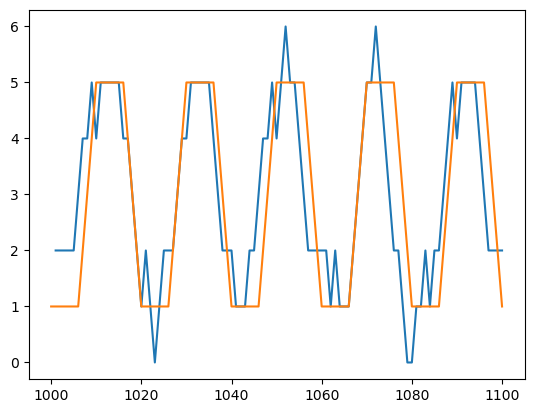

5000
(5000, 57) (5000,)
[4.29655148 0.79310124 1.29654862] [0.24604826 1.5862059  0.05584444]
5000 train done
1.2828328190573524


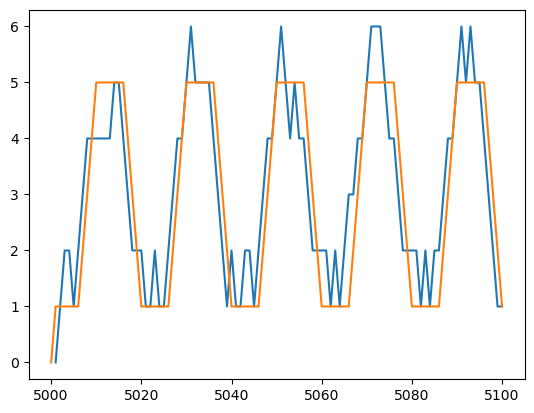

20000
(20000, 57) (20000,)
[0.18220457 0.68004723 0.79310124] [0.25310072 1.29654862 0.64826954]
20000 train done
1.7856218983942158


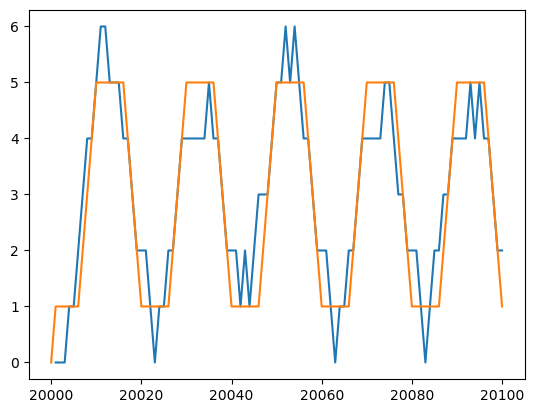

40000
(40000, 57) (40000,)
[2.59310295 2.59310295 0.68004723] [0.53706774 0.44676701 3.57413787]
40000 train done
1.1894188906510699


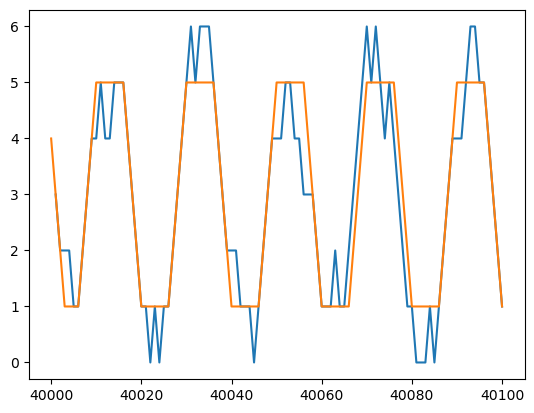

60000
(60000, 57) (60000,)
[0.09110057 0.36441119 0.36441119] [0.68004723 0.44676701 0.408502  ]
60000 train done
1.3278163078754703


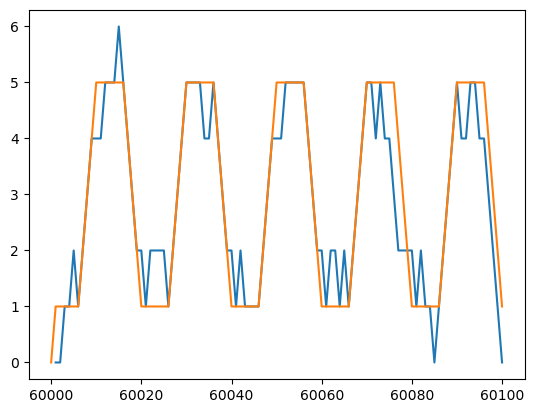

80000
(80000, 57) (80000,)
[1.01241181 3.57413787 4.29655148] [0.89353447 2.59310295 0.72882362]
80000 train done
1.0214387896923198


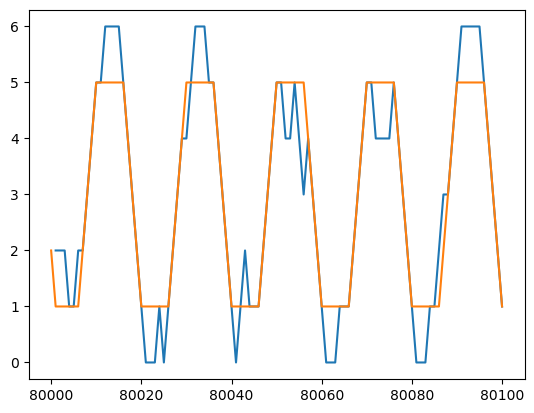

'\nFUTURE_STATE_arr = np.vstack(FUTURE_STATE)\nnp.savez(\n    f"../results/PVFM/RF_optimal_oh_w_time1000_640000_lookahead{t_prime}_reps{0}.npz",\n    future_states =FUTURE_STATE_arr\n    )\n'

In [44]:
# Oracle NN
DELTA_t = 20
t_prime = 6
Ts = [1000,5000,20000,40000,60000,80000]
#Ts = [1280000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
FUTURE_STATE = []
np.random.seed(1998)
for T in Ts:
    # n_seq = int(T/(DELTA_t+1))
    n_seq = T
    print(n_seq)
    state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
    time_raw = np.random.choice([int(i) for i in range(T-DELTA_t)],size = n_seq)
    opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
    STATES = []
    for i in range(len(time_raw)):
        path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
        # print(state_raw[i],path)
        times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
        opt_paths.append(path)
        opt_irewards.append(rewards)
        opt_times.append(times)
        opt_prewards.append(preward_opt(rewards[1:],gamma = gamma))
        state_posencode_oh = position_encoder(np.array(path), type="onehot")
        time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
        # print(time_emb.shape,state_posencode_oh.shape)
        state_pe = np.hstack([state_posencode_oh,time_emb])
        STATES.append(state_pe[0,:])
    STATES_arr = np.vstack(STATES)
    REWARDS_arr = np.hstack(np.array(opt_prewards).reshape(-1,1))
    print(STATES_arr.shape,REWARDS_arr.shape)
    print(REWARDS_arr[:3],REWARDS_arr[-3:])
    X_train = STATES_arr
    Y_train = REWARDS_arr
    # rf = RandomForestRegressor(n_estimators=1000, random_state=515)
    ## Using XGB regressor with delta = 1 is converging faster -- 150
    rf = MLPRegressor(
    hidden_layer_sizes=(128, 128),  #  MLP Layer structure
    solver='adam',
    learning_rate_init=1e-2,
    max_iter=5000,
    random_state=42,
    early_stopping=False,           
    verbose=False
            )
    rf.fit(X_train, Y_train)
    print(T,'train done')

    
    current_state = np.random.choice([int(i) for i in range(7)],size = 1)
    future_states = [current_state.item()]
    # print(current_state)
    irewards_test = []
    for delta_t in range(100):
        df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
        n_paths = df_all_paths.shape[0]
        prewards_pred = np.zeros((n_paths,  t_prime+1))
        for i in range(t_prime+1):
            cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
            curr_time = T+1+delta_t+i
            time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
            features = np.hstack([cand_pe,time_emb])
            prewards_pred[:,i] = rf.predict(features)
        idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
        best_idx = np.argmax(prewards_pred[:, 1])
        best_path = df_all_paths.iloc[best_idx,:]
        next_state = np.array(best_path)[1]
        future_states.append(next_state.item())
        irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
        current_state = next_state
    # print(T,future_states,len(future_states))
    FUTURE_STATE.append(future_states)

    irewards = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
    preward = compute_normalized_future_rewards(irewards,100,gamma)
    path, ireward_opt = path_opt(future_states[0], T, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
    pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
    print(pregret)
    plt.plot(np.arange(T+1,T+101),future_states[1:])
    plt.plot(np.arange(T,T+101),path)
    plt.show()
"""
FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
np.savez(
    f"../results/PVFM/RF_optimal_oh_w_time1000_640000_lookahead{t_prime}_reps{0}.npz",
    future_states =FUTURE_STATE_arr
    )
"""


training timestamps 1000
1000 train done
2.3451443551561524


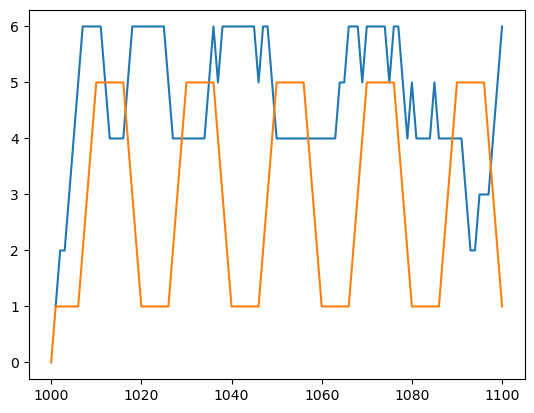

training timestamps 5000
5000 train done
2.2718329723579633


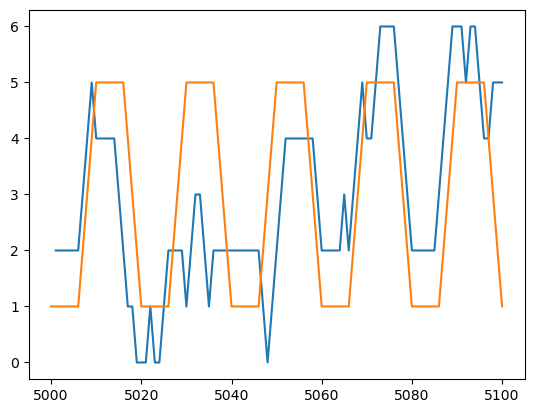

training timestamps 10000
10000 train done
2.1187857561318015


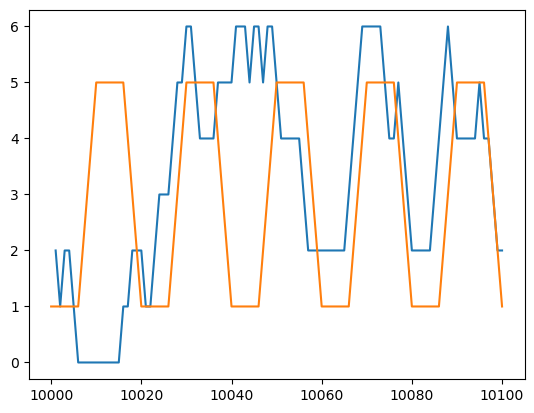

training timestamps 20000
20000 train done
2.1574521251971586


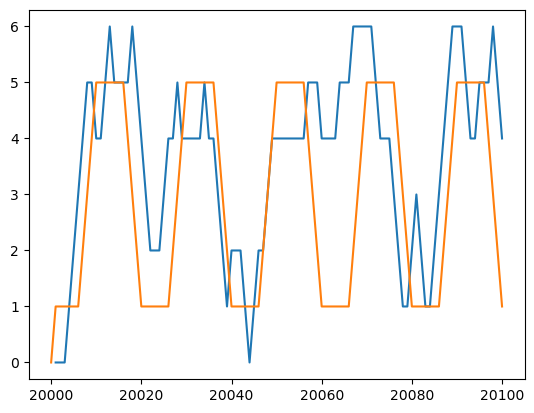

training timestamps 40000
40000 train done
2.09865648412419


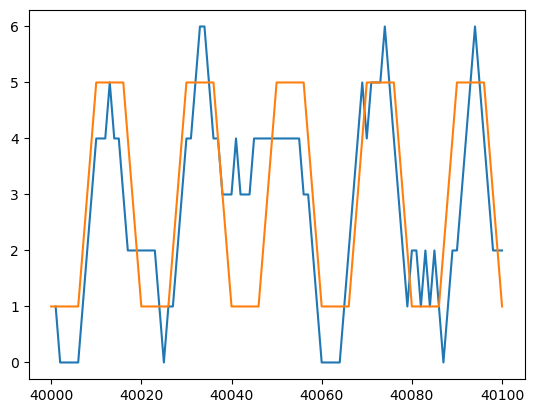

training timestamps 80000
80000 train done
1.666613903980351


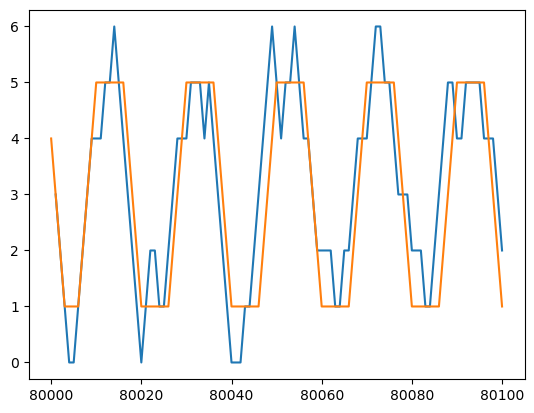

training timestamps 1000
1000 train done
2.4013727587923355


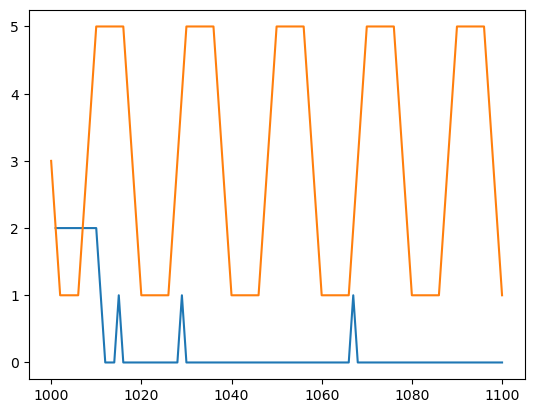

training timestamps 5000
5000 train done
2.2643126150808843


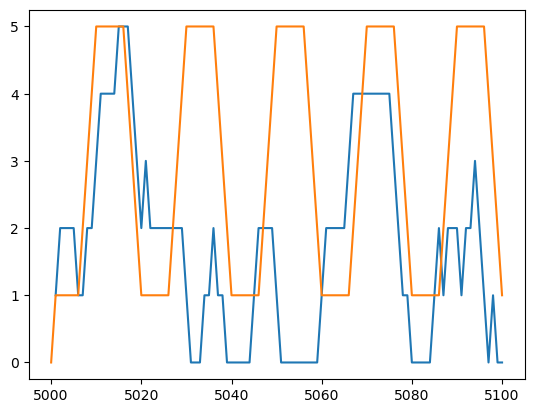

training timestamps 10000
10000 train done
2.1695216569513933


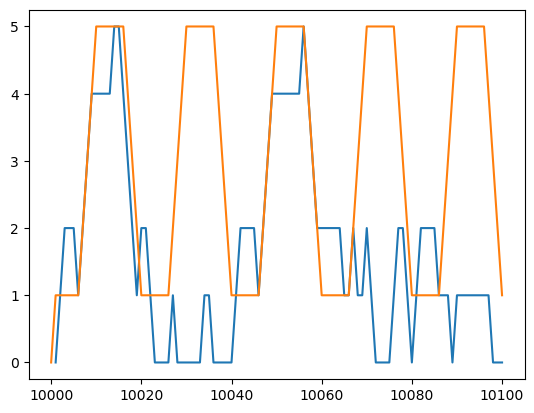

training timestamps 20000
20000 train done
2.0574565597390286


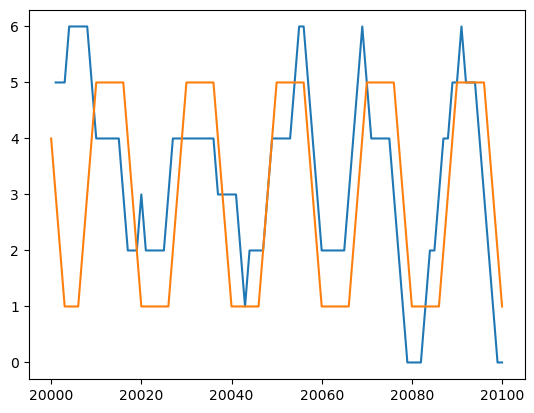

training timestamps 40000
40000 train done
2.080865579766907


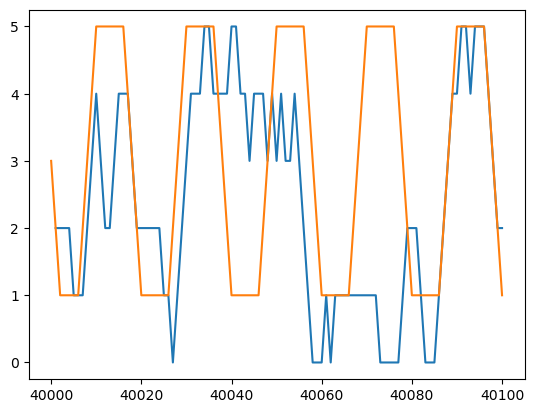

training timestamps 80000
80000 train done
1.9640918136602254


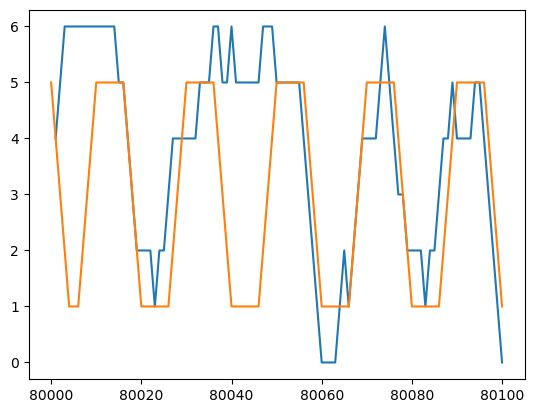

training timestamps 1000
1000 train done
2.32863403862385


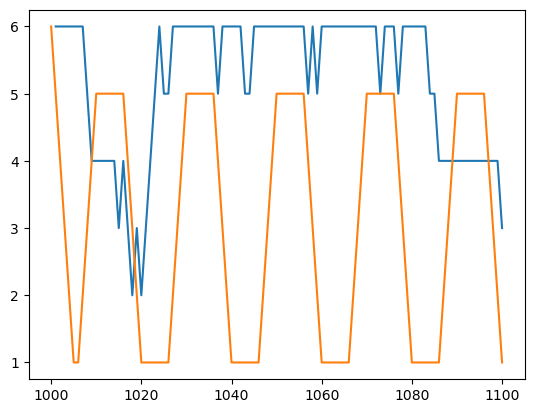

training timestamps 5000
5000 train done
2.1800252176280126


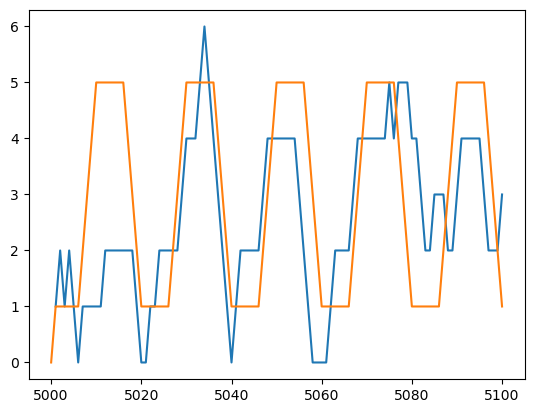

training timestamps 10000
10000 train done
2.1783837401474107


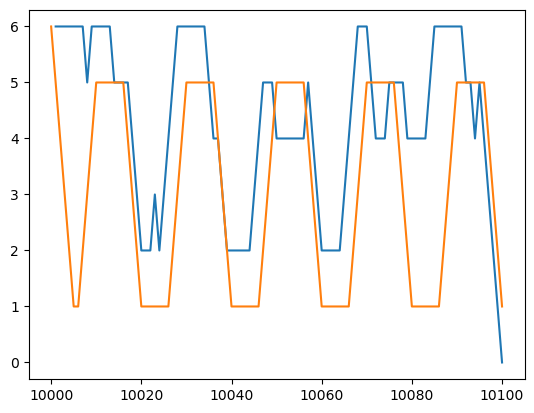

training timestamps 20000
20000 train done
1.7352885698282388


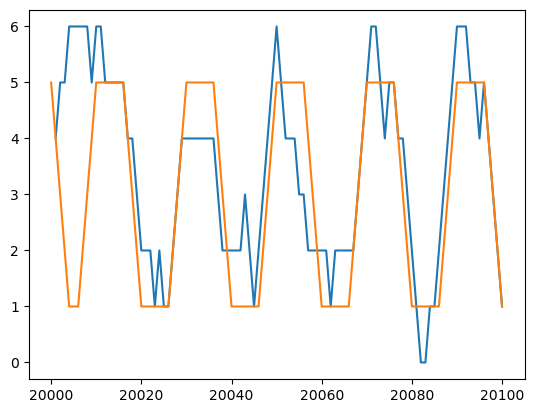

training timestamps 40000
40000 train done
2.236270233694615


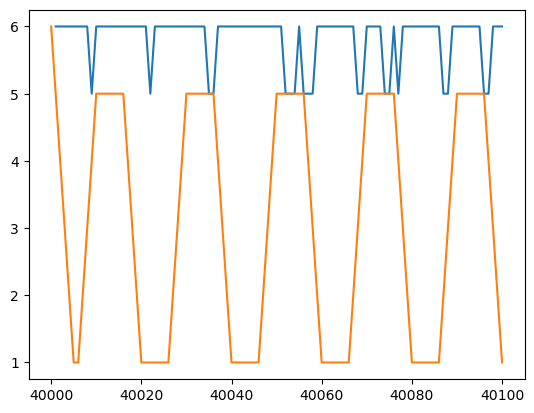

training timestamps 80000
80000 train done
1.692442939501591


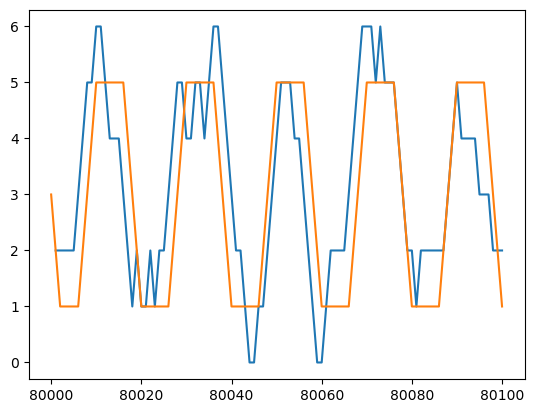

training timestamps 1000
1000 train done
2.3765382094251386


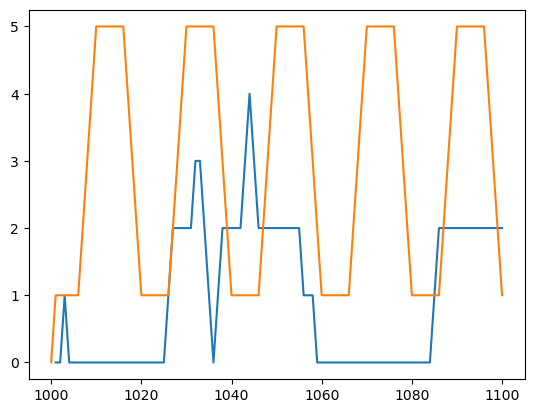

training timestamps 5000
5000 train done
2.1903771125880236


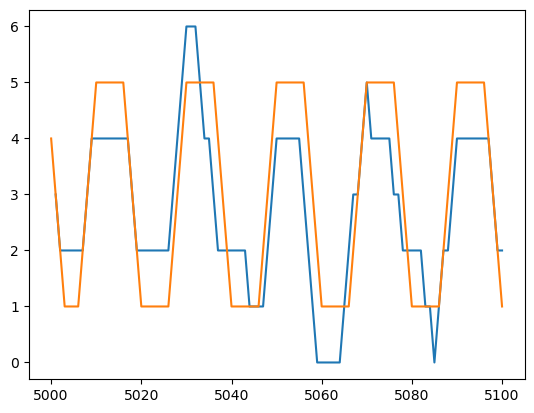

training timestamps 10000
10000 train done
2.119755599284723


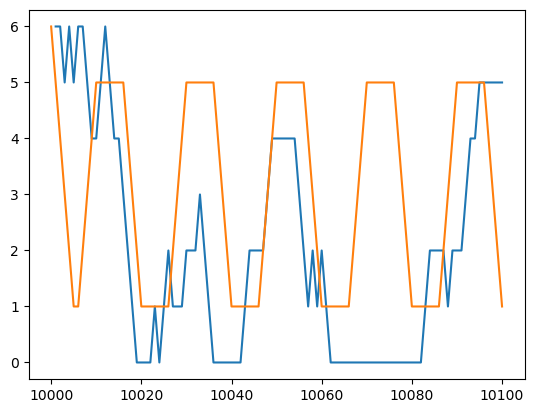

training timestamps 20000
20000 train done
2.103068784455065


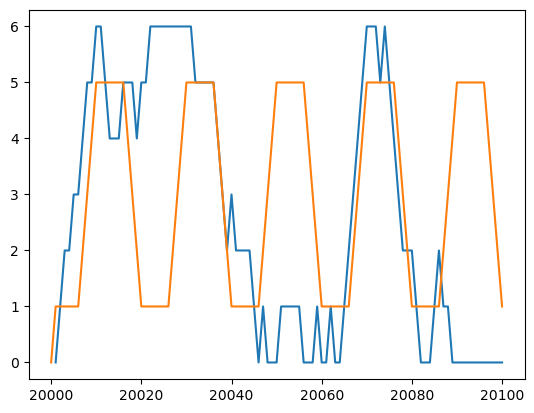

training timestamps 40000
40000 train done
1.9960854129712209


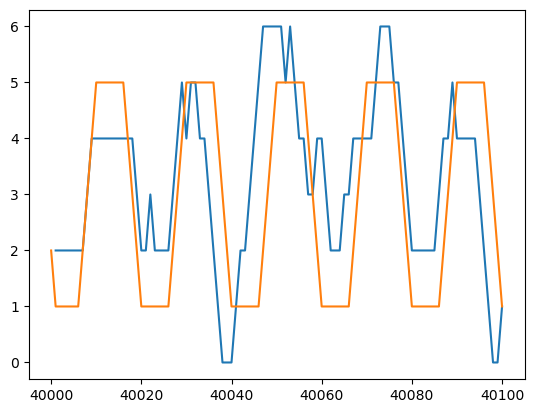

training timestamps 80000
80000 train done
1.6456640621698693


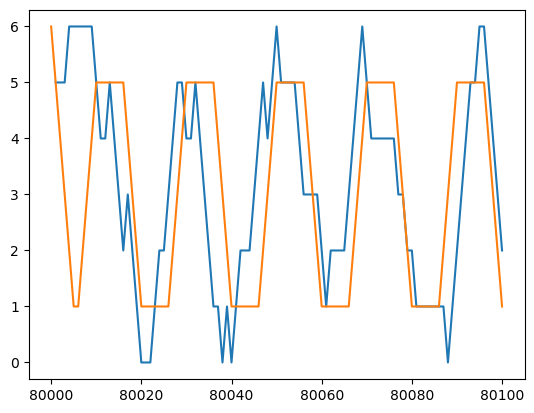

training timestamps 1000
1000 train done
2.294840922540434


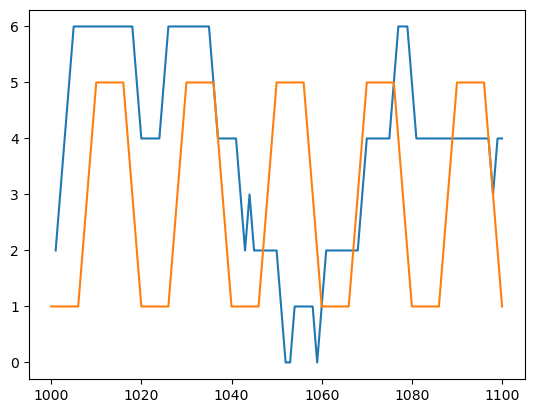

training timestamps 5000
5000 train done
2.181453024852037


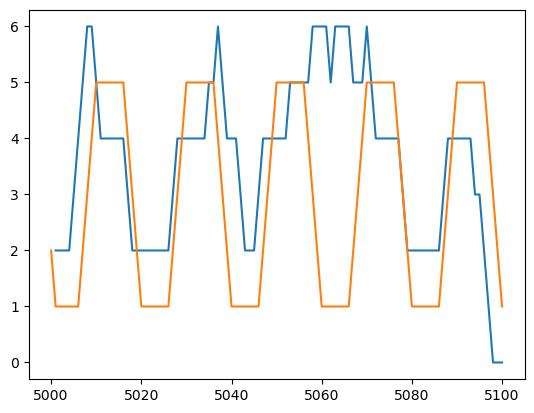

training timestamps 10000
10000 train done
1.9661151827190495


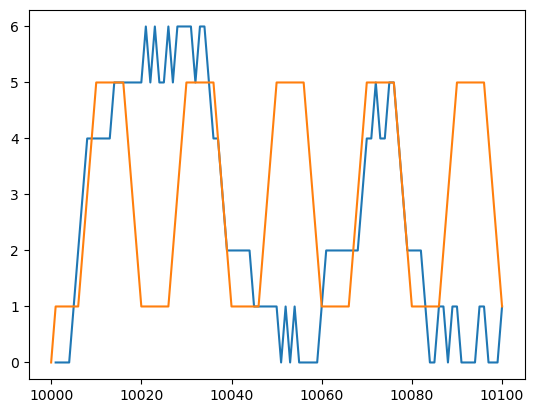

training timestamps 20000
20000 train done
2.1624470767357367


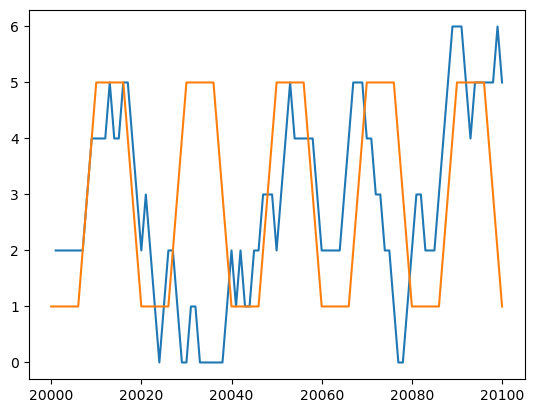

training timestamps 40000
40000 train done
2.127585172337593


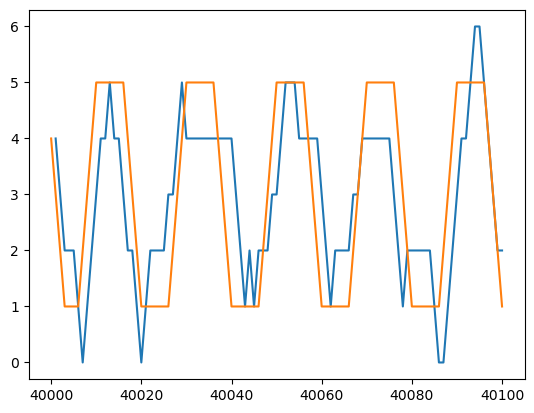

training timestamps 80000
80000 train done
1.6090220330688891


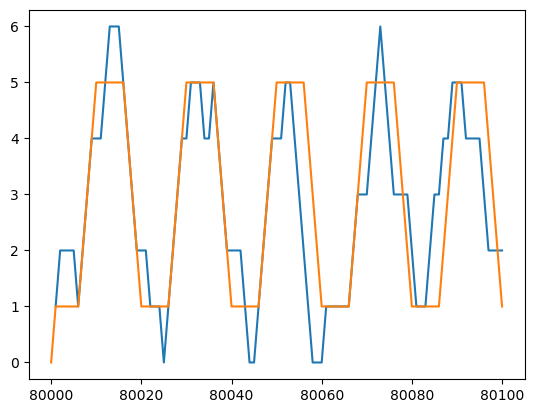

training timestamps 1000
1000 train done
2.2535817945937477


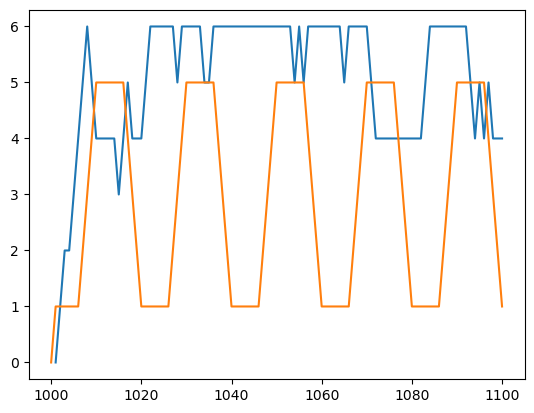

training timestamps 5000
5000 train done
2.1718206071516817


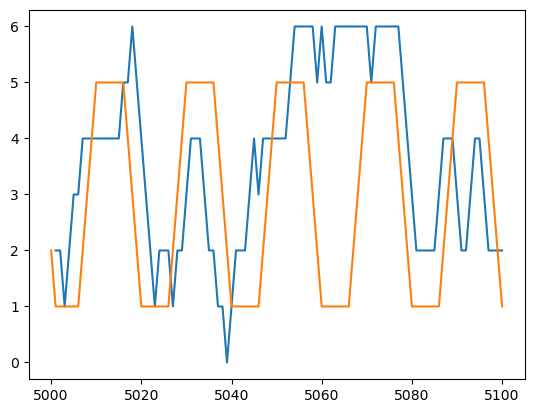

training timestamps 10000
10000 train done
2.0532565843854043


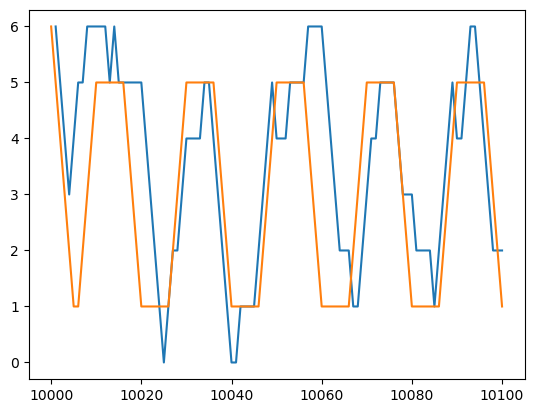

training timestamps 20000
20000 train done
2.0142855922934686


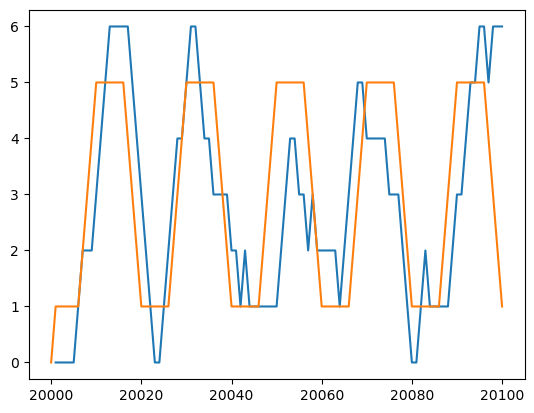

training timestamps 40000
40000 train done
1.9517237056671757


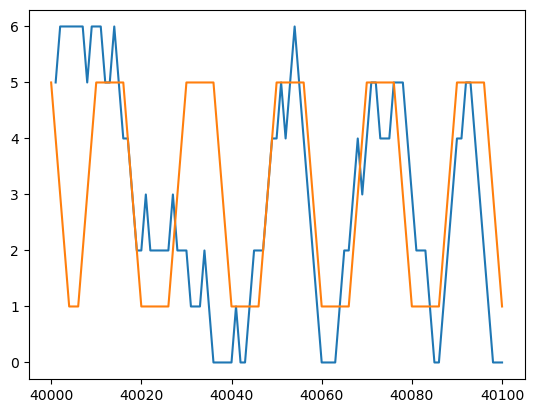

training timestamps 80000
80000 train done
1.8452155170550655


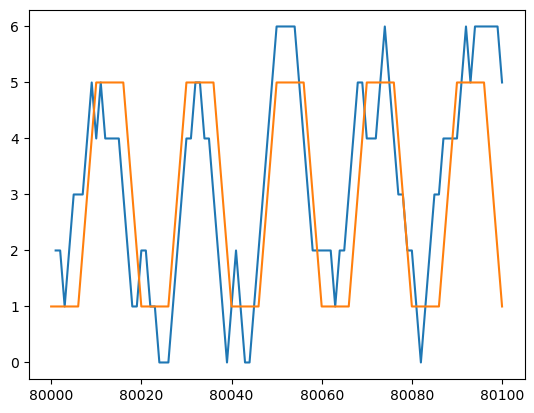

training timestamps 1000
1000 train done
2.249087693044265


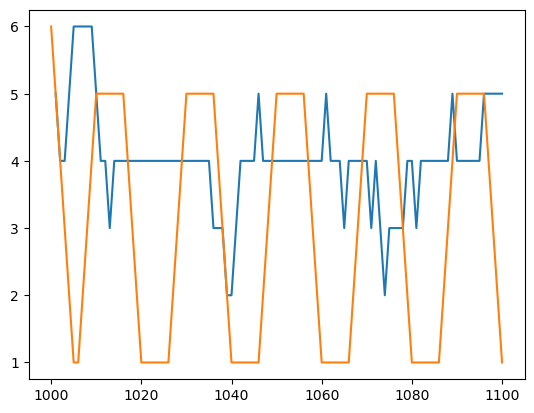

training timestamps 5000
5000 train done
2.1938522808408054


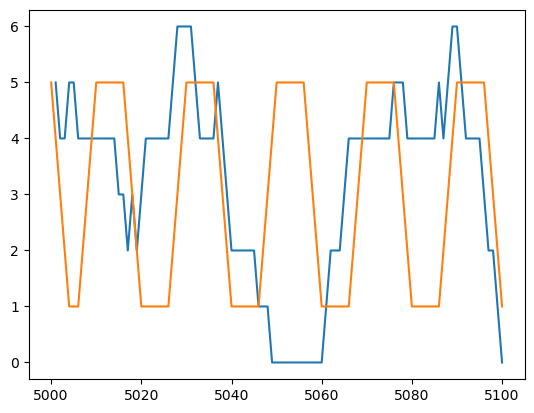

training timestamps 10000
10000 train done
2.2306437471609626


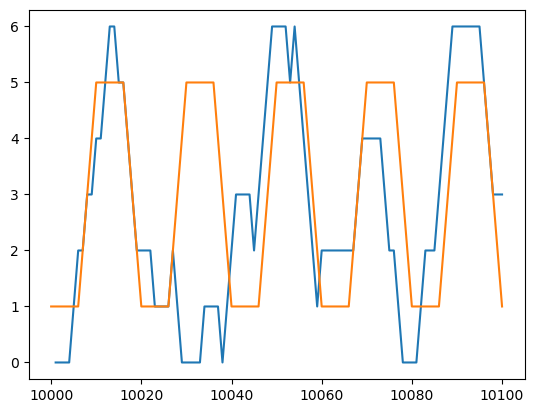

training timestamps 20000
20000 train done
2.0319205127759026


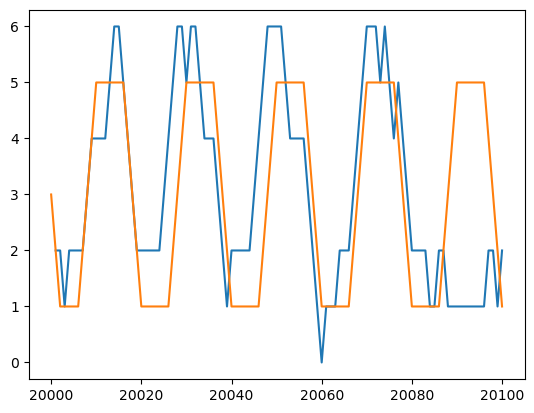

training timestamps 40000
40000 train done
1.9192546560897006


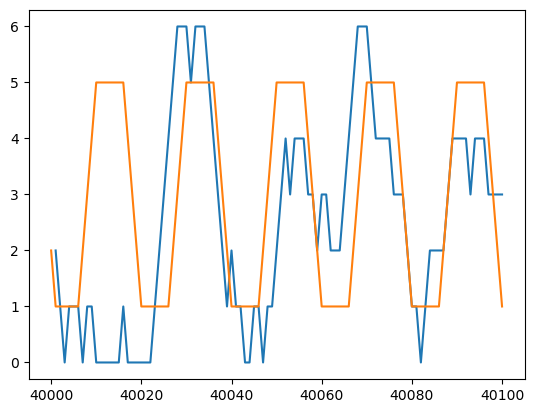

training timestamps 80000
80000 train done
1.9818826824142344


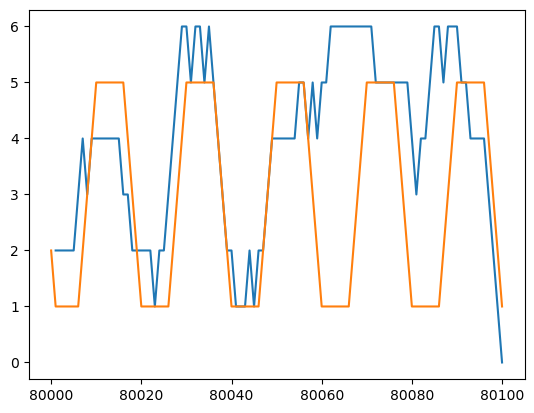

training timestamps 1000
1000 train done
2.1769348080023434


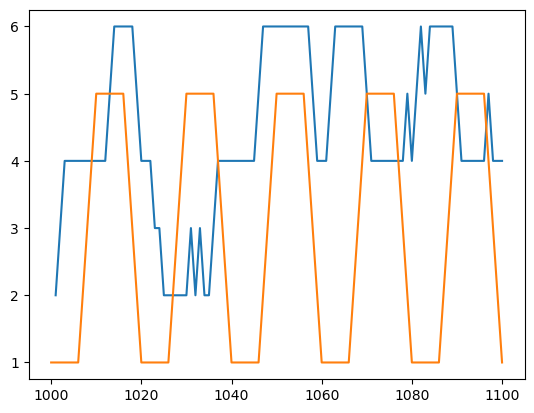

training timestamps 5000
5000 train done
2.1216571801070674


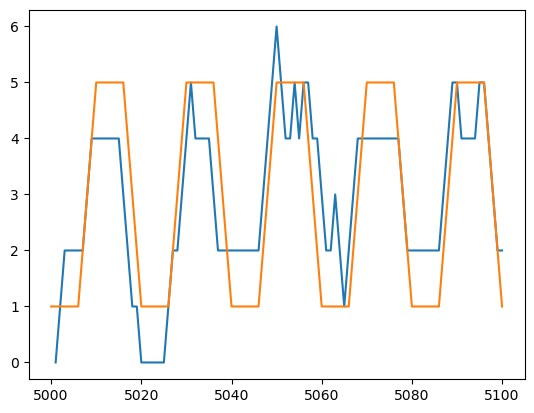

training timestamps 10000
10000 train done
2.0655143980457513


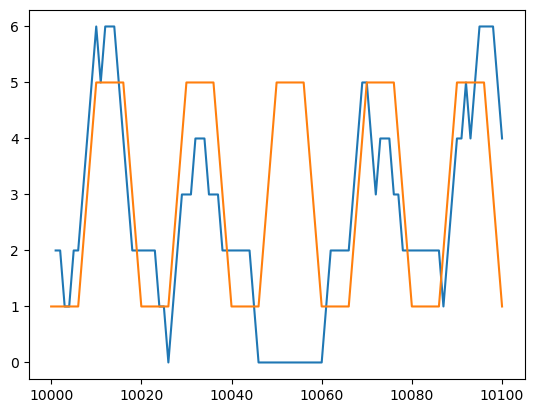

training timestamps 20000
20000 train done
1.9048549398737789


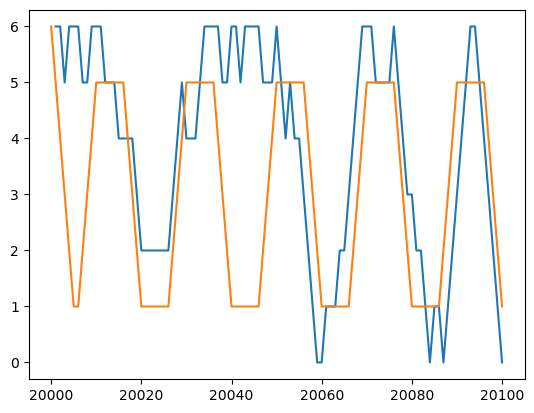

training timestamps 40000
40000 train done
1.8255967764451564


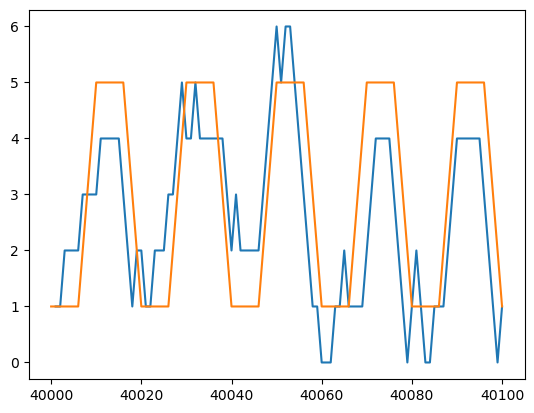

training timestamps 80000
80000 train done
1.9519208621249688


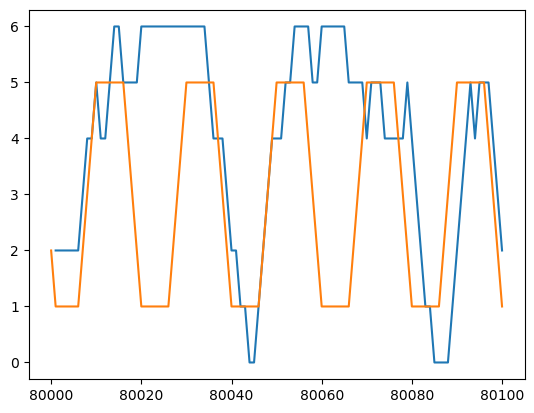

training timestamps 1000
1000 train done
2.269579795309882


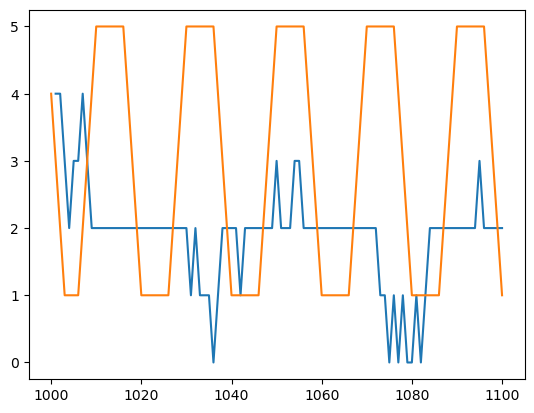

training timestamps 5000
5000 train done
2.054034298125539


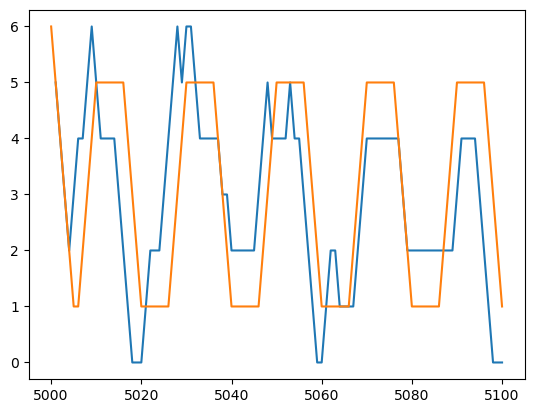

training timestamps 10000
10000 train done
1.9943219138314787


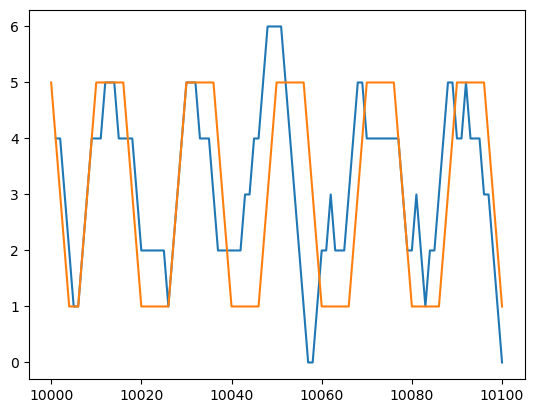

training timestamps 20000
20000 train done
2.205357347307003


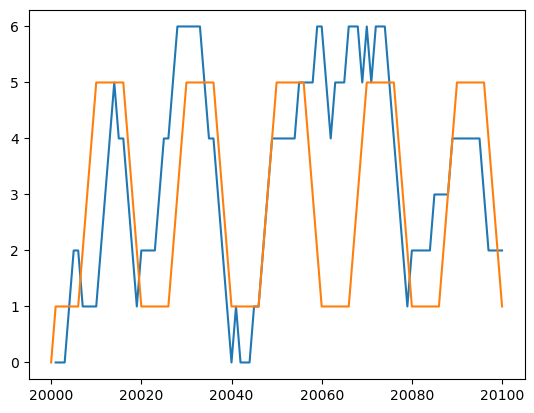

training timestamps 40000
40000 train done
2.023067463856254


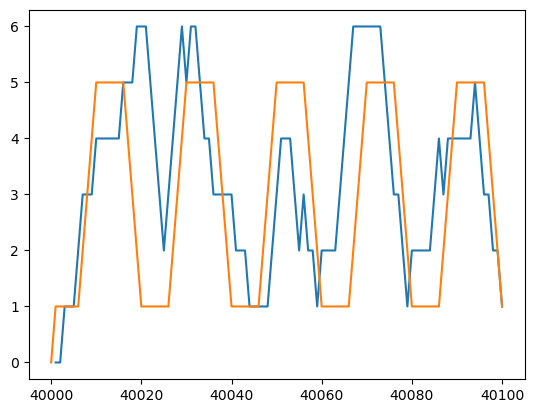

training timestamps 80000
80000 train done
1.9359578346906279


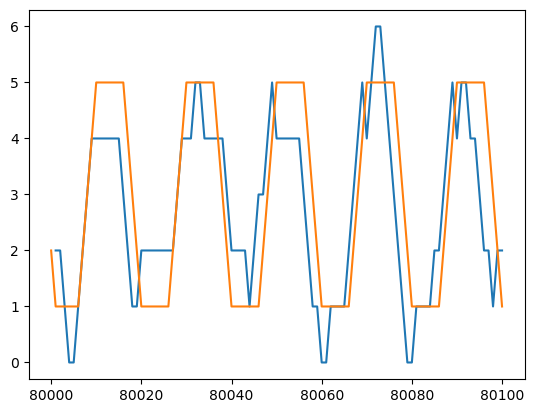

training timestamps 1000
1000 train done
2.1317912447581358


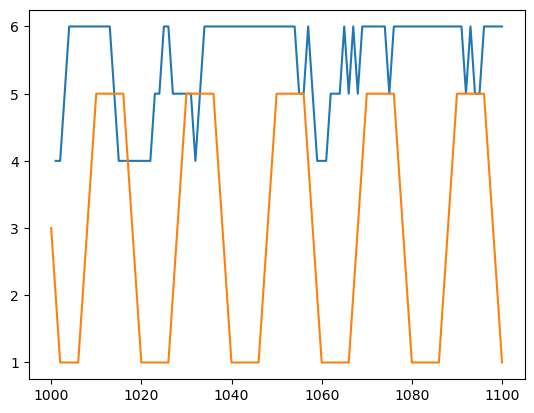

training timestamps 5000
5000 train done
2.2001629995213166


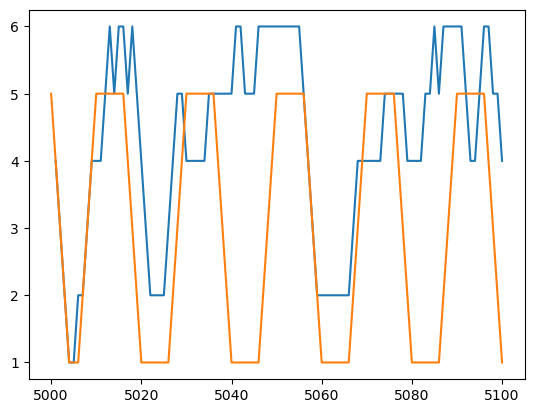

training timestamps 10000
10000 train done
2.061417738401304


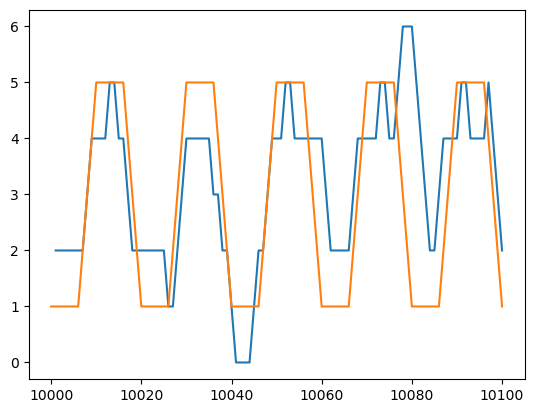

training timestamps 20000
20000 train done
2.1731429760210457


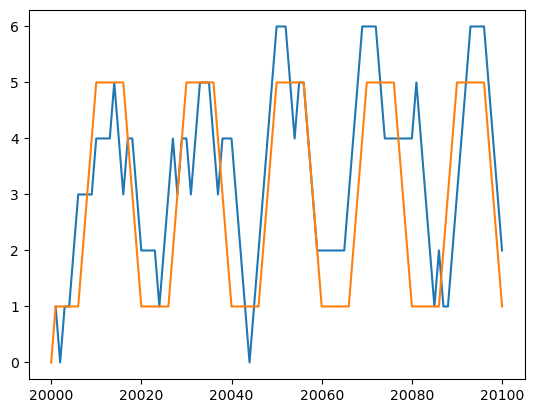

training timestamps 40000
40000 train done
2.227771355892725


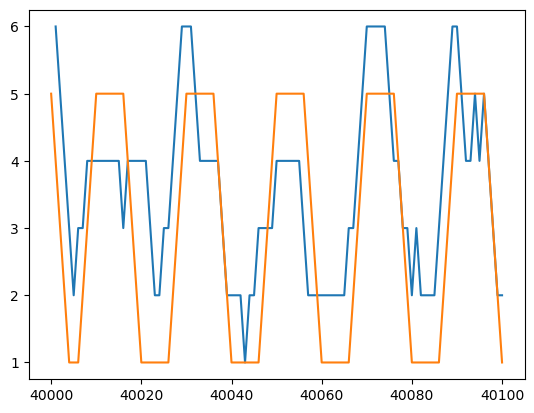

training timestamps 80000
80000 train done
1.5046026780764015


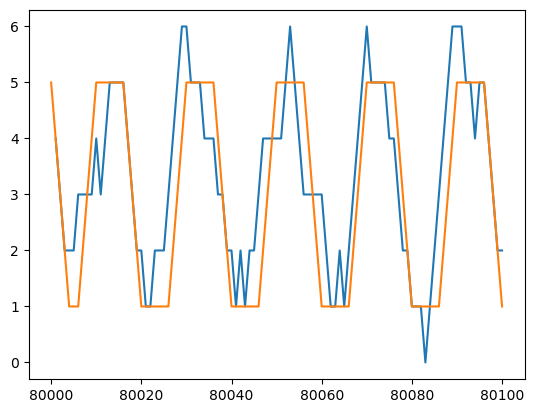

In [ ]:
# one hot 
onehot7 = np.eye(7, dtype=float)
PLOT = False
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000]
gamma = 0.5

for rep in range(10):
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 500000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 8515 +rep)
    np.random.seed(1998 + rep)                                                
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    for T in Ts:
        print('training timestamps', T)
        prewards = make_weighted_target(irewards, gamma ,T = T)
        X_train = new_state_oh[:T,:]
        Y_train = prewards[:T]
        rf= MLPRegressor(
        hidden_layer_sizes=(256, 256),  #  MLP Layer structure
        solver='adam',
        learning_rate_init=1e-2,
        max_iter=5000,
        random_state=42+ rep,
        early_stopping=False,           
        verbose=False
                )
        rf.fit(X_train, Y_train)
        print(T,'train done')
        time_cache = {}   # 缓存: {curr_time: rf.predict(7个状态)}，随 T/模型重置
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                prewards_pred[:,i] = rf.predict(features)
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
            current_state = next_state
        FUTURE_STATE.append(future_states)

        irewards_future = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_future,100,gamma)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()

"""
    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    out_dir = "../results_PVFM" 
    os.makedirs(out_dir, exist_ok=True) 
    np.savez(
        os.path.join(out_dir, f"NN_oh_w_time1000_160000_lookahead{t_prime}_reps{rep}.npz"),
        future_states=FUTURE_STATE_arr
          )
"""